In [1]:
from __future__ import annotations

import os
from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Tuple

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

import torchaudio
from transformers import Wav2Vec2ForPreTraining
from matplotlib import pyplot as plt

import numpy as np
import pandas as pd
import hdbscan
import plotly.express as px

try:
    from . import components
except ImportError:  # pragma: no cover - allows running this file as a script
    import components

Transformer-based neural networks have been revolutionizing the natural language processing field, but are only starting to become popular in the speech processing community. __Wav2vec 2.0__ is set to change that. Its architecture is based on the Transformer’s encoder, with a training objective similar to [__BERT’s masked language modeling objective__](https://arxiv.org/abs/1810.04805), but adapted for speech.

This new method allows for efficient __semi-supervised training__: 
* pre-training the model on a large quantity of unlabeled speech
* then fine-tuning on a smaller labeled dataset.

In __[wav2vec 2.0’s original paper](https://arxiv.org/abs/2006.11477)__, the authors demonstrated that fine-tuning the model on only one hour of labeled speech data could beat the previous state-of-the-art systems trained on 100 times more labeled data.



![wav2vec2_architecture_pretraining](https://jonathanbgn.com/assets/images/illustrated-wav2vec/wav2vec2_architecture_pretraining.png)

In [2]:
@dataclass(kw_only=True)
class Config:
    extractor_mode: str = "group_norm"
    extractor_conv_layer_config: Optional[List[Tuple[int, int, int]]] = None
    extractor_conv_bias: bool = False

    encoder_embed_dim: int = 768
    encoder_projection_dropout: float = 0.1
    encoder_pos_conv_kernel: int = 128
    encoder_pos_conv_groups: int = 16
    encoder_num_layers: int = 12
    encoder_num_heads: int = 12
    encoder_attention_dropout: float = 0.1
    encoder_ff_interm_features: int = 3072
    encoder_ff_interm_dropout: float = 0.1
    encoder_dropout: float = 0.1
    encoder_layer_norm_first: bool = False
    encoder_layer_drop: float = 0.1

    load_pretrained: bool = True
    dl_kwargs: Optional[Dict[str, Any]] = None
    strict: bool = True

    codevector_dim: int = 256
    num_codevector_groups: int = 2
    num_codevectors_per_group: int = 320
    proj_codevector_dim: int = 256

    num_negatives: int = 100
    contrastive_logits_temperature: float = 0.1
    diversity_loss_weight: float = 0.1

    feature_grad_mult: Optional[float] = 0.0
    feat_quantizer_dropout: float = 0.0

    mask_prob = 0.05
    mask_length = 10
    target_sample_rate = 16000

cfg = Config()

# Feature encoder

The feature encoder’s job is to reduce the dimensionality of the audio data, converting the raw waveform into a sequence of feature vectors $Z_0, Z_1, Z_2, …, Z_T$ each 20 milliseconds. Its architecture is simple: a 7-layer convolutional neural network (single-dimensional) with 512 channels at each layer.

![](https://jonathanbgn.com/assets/images/illustrated-wav2vec/wav2vec2_feature_encoder.png)

The waveform is normalized before being sent to the network, and the kernel width and strides of the convolutional layers decrease as we get higher in the network. The feature encoder has a total receptive field of 400 samples or 25 ms of audio (audio data is encoded at a sample rate of 16 kHz).

```python
class ConvLayerBlock(Module):
    """Convolution unit of FeatureExtractor"""

    def __init__():
        ...

    def forward():
        ...
    
        x = self.conv(x)
        if self.layer_norm is not None:
            x = self.layer_norm(x)
        x = nn.functional.gelu(x)
        ...
        
        return x, length
```

In [3]:
if cfg.extractor_conv_layer_config is None:
    cfg.extractor_conv_layer_config = [(512, 10, 5)] + [(512, 3, 2)] * 4 + [(512, 2, 2)] * 2

feature_extractor = components._get_feature_extractor(
    cfg.extractor_mode, 
    cfg.extractor_conv_layer_config, 
    cfg.extractor_conv_bias
)

In [4]:
feature_extractor

FeatureExtractor(
  (conv_layers): ModuleList(
    (0): ConvLayerBlock(
      (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
      (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
    )
    (1-4): 4 x ConvLayerBlock(
      (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
    )
    (5-6): 2 x ConvLayerBlock(
      (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
    )
  )
)

# Quantization module & Gumbel Softmax

### 1. High-Level Explanation: What does this code do?
This class implements the **Discrete Tokenizer** used in the **Wav2Vec 2.0** architecture. 

In standard NLP models (like BERT), the input is already discrete (words/subwords). But in speech recognition, the input is continuous audio waves. To use BERT-style masked training on audio, Wav2Vec 2.0 needs a way to turn continuous audio features into discrete "speech units" or "tokens."

This class solves two major problems to achieve this:
1. **Product Quantization:** If you want a vocabulary of $1,000,000$ audio tokens, a standard embedding table would be massively inefficient. Instead, it uses $G$ groups (e.g., 2) and $V$ variables per group (e.g., 320). It picks one vector from group 1 and concatenates it with a vector from group 2. This creates $320 \times 320 = 102,400$ possible combinations while only storing $640$ vectors.
2. **The Non-Differentiability Problem:** Picking a discrete token requires an `argmax` operation. You cannot backpropagate gradients through an `argmax` because its derivative is zero almost everywhere. To fix this, it uses the **Gumbel-Softmax Trick**, which provides a differentiable approximation of `argmax` during training.

---

### 2. Core Concepts Explained

#### A. Gumbel-Softmax (The Differentiable Argmax)
Normally, picking a codebook entry looks like this: $i = \text{argmax}(\text{logits})$. 
Gumbel-Softmax introduces noise ($g$, sampled from a Gumbel distribution) and a temperature ($\tau$) to make it a soft, differentiable probability distribution:
$$ p_i = \frac{\exp((\text{logit}_i + g_i) / \tau)}{\sum_j \exp((\text{logit}_j + g_j) / \tau)} $$
*   When $\tau \to \infty$, the distribution is completely uniform.
*   When $\tau \to 0$, it behaves exactly like a hard `argmax`.
The code uses `hard=True`. This means the *forward pass* acts as a strict `argmax` (returning one-hot vectors), but the *backward pass* routes the gradients through the continuous equation above (this is called the **Straight-Through Estimator**).

#### B. [Codebook Perplexity](https://en.wikipedia.org/wiki/Perplexity) (Preventing Mode Collapse)
A common failure in Vector Quantization is "index collapse," where the model gets lazy and only uses 2 or 3 tokens for every audio frame, ignoring the rest of the codebook. 
To monitor and prevent this, the code calculates **Perplexity**. It measures how uniformly the codebook is being used. 
$$ \text{Perplexity} = e^{H(p)} = \exp\left(-\sum p_i \log p_i\right) $$
where $p_i$ is the marginal probability of choosing token $i$ across the whole batch. The model tries to maximize this value to ensure all tokens are utilized.

![wav2vec2_quantization_module](https://jonathanbgn.com/assets/images/illustrated-wav2vec/wav2vec2_quantization_module.png)

In [5]:
class Wav2Vec2GumbelVectorQuantizer(nn.Module):
    """Vector quantization using Gumbel-Softmax.
    
    Discretizes continuous feature vectors using product quantization with
    Gumbel-Softmax relaxation for differentiable training.
    """

    def __init__(
        self,
        input_dim: int,
        codevector_dim: int,
        num_groups: int,  # Theory: G (e.g., 2). Number of sub-codebooks.
        num_vars: int,    # Theory: V (e.g., 320). Number of entries per sub-codebook.
    ):
        super().__init__()
        self.num_groups = num_groups
        self.num_vars = num_vars

        # Product Quantization requires the target dimension to be evenly 
        # split among the G groups. If dim=256 and G=2, each group yields a 128-dim slice.
        assert (
            codevector_dim % num_groups == 0
        ), f"`codevector_dim {codevector_dim} must be divisible by `num_groups` {num_groups}"

        # Codebook: shape (1, G * V, D / G)
        # This stores the actual physical vectors. We store them flattened as one matrix 
        # for efficient batch multiplication later. Total theoretical combinations = V^G.
        self.codevectors = nn.Parameter(
            torch.FloatTensor(1, num_groups * num_vars, codevector_dim // num_groups)
        )
        
        # Linear projection to generate logits for each variable in each group.
        # Maps Input_Dim -> G * V. 
        self.weight_proj = nn.Linear(input_dim, num_groups * num_vars)

        # Tau (τ) 
        self.temperature = 2.0

        nn.init.uniform_(self.codevectors)

    def set_temperature(self, temperature: float):
        """Set the Gumbel-Softmax temperature (used by learning rate schedulers)."""
        self.temperature = temperature

    @staticmethod
    def _compute_perplexity(probs: Tensor, mask: Optional[Tensor] = None) -> Tensor:
        """Compute perplexity of codebook usage distribution.
        
        Max perplexity is V. If Perplexity drops to 1, the model is suffering 
        from severe mode collapse (using only 1 codevector).
        """
        if mask is not None:
            # In Wav2Vec2, loss is often only computed on masked frames.
            # We only want to measure codebook usage on valid/masked time steps.
            mask_extended = mask.flatten()[:, None, None].expand(probs.shape)
            probs = torch.where(mask_extended, probs, torch.zeros_like(probs))
            # Marginal probability p_i = (Sum of probabilities for code i) / (Total valid frames)
            marginal_probs = probs.sum(dim=0) / mask.sum()
        else:
            # Average usage of each code across the batch and sequence length
            marginal_probs = probs.mean(dim=0)

        # Theory: Entropy H = -Sum(p * log(p)). Perplexity = exp(H).
        # We add 1e-7 inside the log to prevent log(0) which causes NaN errors.
        perplexity = torch.exp(-torch.sum(marginal_probs * torch.log(marginal_probs + 1e-7), dim=-1)).sum()
        return perplexity

    def forward(
        self,
        hidden_states: Tensor,
        mask_time_indices: Optional[Tensor] = None,
    ) -> Tuple[Tensor, Tensor]:
        """
        Forward Pass Flow:
        1. Map continuous hidden_states -> logits
        2. Convert logits -> probabilities (Gumbel-Softmax/Argmax)
        3. Use probabilities as weights to mix/select the actual codevectors.
        """
        batch_size, sequence_length, hidden_size = hidden_states.shape

        # Step 1: Project continuous vectors to logits for codebook selection.
        # Shape becomes (B, T, G * V)
        hidden_states = self.weight_proj(hidden_states)
        
        # Reshape so we process each group independently.
        # Shape: (B * T * G, V). Every row represents one group's logits to pick from V vars.
        hidden_states = hidden_states.view(batch_size * sequence_length * self.num_groups, -1)

        if self.training:
            # Step 2 (Training): Sample codevector indices via Gumbel-Softmax.
            # hard=True uses the "Straight-Through Estimator": 
            #   - Forward pass: returns strictly One-Hot vectors (like argmax).
            #   - Backward pass: behaves as if it returned the soft probabilities, allowing gradient flow.
            codevector_probs = F.gumbel_softmax(
                hidden_states.float(), tau=self.temperature, hard=True
            ).type_as(hidden_states)

            # Compute perplexity from soft distribution (without Gumbel noise) 
            # to get an accurate representation of the model's true confidence.
            codevector_soft_dist = torch.softmax(
                hidden_states.view(batch_size * sequence_length, self.num_groups, -1).float(), dim=-1
            )
            perplexity = self._compute_perplexity(codevector_soft_dist, mask_time_indices)
        else:
            # Step 2 (Inference): No gradients needed. Standard hard Argmax.
            codevector_idx = hidden_states.argmax(dim=-1)
            
            # Create a one-hot tensor mathematically identical to the forward pass of `hard=True`
            codevector_probs = hidden_states.new_zeros(*hidden_states.shape).scatter_(
                -1, codevector_idx.view(-1, 1), 1.0
            )
            
            # Reshape for perplexity calculation
            codevector_probs = codevector_probs.view(batch_size * sequence_length, self.num_groups, -1)
            perplexity = self._compute_perplexity(codevector_probs, mask_time_indices)

        # Flatten out the groups again. Shape: (B * T, G * V)
        codevector_probs = codevector_probs.view(batch_size * sequence_length, -1)

        # Step 3: Retrieve codevectors using probabilities.
        # Theory: Because codevector_probs is One-Hot, multiplying it with self.codevectors 
        # is mathematically equivalent to an embedding lookup, but it keeps the computation 
        # graph intact so gradients can flow backward to the projection weights.
        
        # Shapes: codevector_probs.unsqueeze(-1) -> (B * T, G * V, 1)
        #         self.codevectors               -> (1,     G * V, D / G)
        # Broadcasting multiplies the 1 or 0 by the specific codevector chunk.
        codevectors_per_group = codevector_probs.unsqueeze(-1) * self.codevectors
        
        # Re-arrange and sum to extract the chosen chunks and concatenate them.
        codevectors = (
            # Reshape to (B * T, G, V, D / G)
            codevectors_per_group.view(batch_size * sequence_length, self.num_groups, self.num_vars, -1)
            # Sum over V (dimension 2). Since it's one-hot, V-1 of these are zero vectors. 
            # This extracts the exactly chosen vector for each of the G groups.
            # Shape becomes (B * T, G, D / G)
            .sum(-2)
            # View flattens G and D/G. This implicitly concatenates the G chunks together!
            # Shape becomes (B, T, D) -> The final quantized representation!
            .view(batch_size, sequence_length, -1)
        )

        return codevectors, perplexity

# Wav2Vec2 model

The core of wav2vec 2.0 is its Transformer encoder, which takes as input the latent feature vectors and processes it through 12 Transformer blocks for the BASE version of the model, or 24 blocks for the LARGE version. To match the inner dimension of the Transformer encoder, the input sequence first needs to go through a feature projection layer to increase the dimension from 512 (output of the CNN) to 768 for BASE or 1,024 for LARGE.

![](https://jonathanbgn.com/assets/images/illustrated-wav2vec/wav2vec2_context_network_transformer.png)

One difference from the original Transformer architecture is how positional information is added to the input. Since the self-attention operation of the Transformer doesn’t preserve the order of the input sequence, fixed pre-generated positional embeddings were added to the input vectors in the original implementation. The wav2vec model instead uses a new __[grouped convolution layer](https://blog.yani.ai/filter-group-tutorial/)__ to learn relative positional embeddings by itself.

In [6]:
encoder = components._get_encoder(
    in_features=cfg.extractor_conv_layer_config[-1][0],
    embed_dim=cfg.encoder_embed_dim,
    dropout_input=cfg.encoder_projection_dropout,
    pos_conv_kernel=cfg.encoder_pos_conv_kernel,
    pos_conv_groups=cfg.encoder_pos_conv_groups,
    num_layers=cfg.encoder_num_layers,
    num_heads=cfg.encoder_num_heads,
    attention_dropout=cfg.encoder_attention_dropout,
    ff_interm_features=cfg.encoder_ff_interm_features,
    ff_interm_dropout=cfg.encoder_ff_interm_dropout,
    dropout=cfg.encoder_dropout,
    layer_norm_first=cfg.encoder_layer_norm_first,
    layer_drop=cfg.encoder_layer_drop,
)

In [48]:
encoder

Encoder(
  (feature_projection): FeatureProjection(
    (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    (projection): Linear(in_features=512, out_features=768, bias=True)
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): Transformer(
    (pos_conv_embed): ConvolutionalPositionalEmbedding(
      (conv): ParametrizedConv1d(
        768, 768, kernel_size=(128,), stride=(1,), padding=(64,), groups=16
        (parametrizations): ModuleDict(
          (weight): ParametrizationList(
            (0): _WeightNorm()
          )
        )
      )
    )
    (layer_norm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (dropout): Dropout(p=0.1, inplace=False)
    (layers): ModuleList(
      (0-11): 12 x EncoderLayer(
        (attention): SelfAttention(
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (q_proj): Linear(in_features=768, out_featur

In [49]:
quantizer_input_dim = encoder.feature_projection.projection.in_features
quantizer = Wav2Vec2GumbelVectorQuantizer(
    input_dim=quantizer_input_dim,
    codevector_dim=cfg.codevector_dim,
    num_groups=cfg.num_codevector_groups,
    num_vars=cfg.num_codevectors_per_group,
)

# Pre-training 

In [9]:
class Wav2Vec2Model(nn.Module):
    """Wav2Vec2 model for both pretraining and fine-tuning.

    When used for pretraining (quantizer provided), implements contrastive learning:
    - Mask spans of feature extractor outputs
    - Predict quantized representations at masked positions
    - Contrastive loss against distractors + diversity loss for codebook usage

    When used for fine-tuning/inference (quantizer=None), provides standard encoder outputs.

    Args:
        feature_extractor (torch.nn.Module): Feature extractor for raw audio.
        encoder (torch.nn.Module): Transformer encoder.
        aux (torch.nn.Module or None, optional): Auxiliary head for fine-tuning.
        quantizer (Wav2Vec2GumbelVectorQuantizer or None, optional): Vector quantizer for pretraining.
        proj_codevector_dim (int or None, optional): Dimension for contrastive projection.
        num_negatives (int): Number of negative samples for contrastive loss.
        contrastive_logits_temperature (float): Temperature for contrastive loss.
        diversity_loss_weight (float): Weight for diversity loss term.
        feature_grad_mult (float or None): Gradient multiplier for feature extractor.
        feat_quantizer_dropout (float): Dropout rate before quantizer.
    """

    def __init__(
        self,
        feature_extractor: nn.Module,
        encoder: nn.Module,
        aux: Optional[nn.Module] = None,
        quantizer: Optional[Wav2Vec2GumbelVectorQuantizer] = None,
        proj_codevector_dim: Optional[int] = None,
        num_negatives: int = 100,
        contrastive_logits_temperature: float = 0.1,
        diversity_loss_weight: float = 0.1,
        feature_grad_mult: Optional[float] = None,
        feat_quantizer_dropout: float = 0.0,
    ):
        super().__init__()
        self.feature_extractor = feature_extractor
        self.encoder = encoder
        self.aux = aux
        self.quantizer = quantizer
        self.num_negatives = num_negatives
        self.contrastive_logits_temperature = contrastive_logits_temperature
        self.diversity_loss_weight = diversity_loss_weight
        self.feature_grad_mult = feature_grad_mult
        self.feat_quantizer_dropout = feat_quantizer_dropout

        if quantizer is not None and proj_codevector_dim is not None:
            encoder_embed_dim = encoder.feature_projection.projection.out_features
            codevector_dim = quantizer.codevectors.shape[-1] * quantizer.num_groups
            self.project_q = nn.Linear(codevector_dim, proj_codevector_dim)
            self.project_hid = nn.Linear(encoder_embed_dim, proj_codevector_dim)
            self.dropout_features = nn.Dropout(feat_quantizer_dropout)
            # Learned mask embedding vector for pretraining (same dim as encoder output)
            self.masked_spec_embed = nn.Parameter(torch.Tensor(encoder_embed_dim).uniform_())
        else:
            self.project_q = None
            self.project_hid = None
            self.dropout_features = None
            self.masked_spec_embed = None

    def _scale_feature_gradients(self, features: Tensor) -> Tensor:
        if self.feature_grad_mult is not None and self.feature_grad_mult < 1.0:
            return features * self.feature_grad_mult + features.detach() * (1 - self.feature_grad_mult)
        return features

    def _mask_hidden_states(
        self,
        hidden_states: Tensor,
        mask_time_indices: Optional[Tensor] = None,
    ) -> Tensor:
        """Replace masked positions with learned mask embedding.
        
        Args:
            hidden_states: Tensor of shape (batch, seq_len, hidden_dim).
            mask_time_indices: Boolean tensor of shape (batch, seq_len) where True indicates masked positions.
        
        Returns:
            Tensor with masked positions replaced by self.masked_spec_embed.
        """
        if mask_time_indices is None or self.masked_spec_embed is None:
            return hidden_states
        
        # Clone to avoid in-place modification
        hidden_states = hidden_states.clone()
        hidden_states[mask_time_indices] = self.masked_spec_embed.to(hidden_states.dtype)
        return hidden_states

    @staticmethod
    def _get_attention_mask(features: Tensor, lengths: Optional[Tensor]) -> Optional[Tensor]:
        if lengths is None:
            return None
        batch_size, max_len = features.shape[:2]
        return torch.arange(max_len, device=lengths.device).expand(batch_size, max_len) < lengths[:, None]

    def set_gumbel_temperature(self, temperature: float):
        """Set Gumbel-Softmax temperature for quantizer."""
        self.quantizer.set_temperature(temperature)

    def freeze_feature_extractor(self):
        """Disable gradient computation for feature extractor."""
        for param in self.feature_extractor.parameters():
            param.requires_grad = False

    @staticmethod
    def _get_feature_vector_attention_mask(
        feature_vector_length: int,
        attention_mask: torch.LongTensor,
        output_lengths: Optional[torch.LongTensor] = None,
    ):
        """Compute attention mask for feature vectors from waveform attention mask.

        Args:
            feature_vector_length: Length of feature vector dimension (output of CNN).
            attention_mask: Waveform-level attention mask (1 for valid, 0 for padded).
            output_lengths: Pre-computed feature vector lengths. If None, computed from attention_mask.

        Returns:
            Boolean attention mask for feature vectors (True for valid positions).
        """
        if output_lengths is None:
            # Effectively attention_mask.sum(-1), but not inplace to be able to run
            # on inference mode.
            non_padded_lengths = attention_mask.cumsum(dim=-1)[:, -1]

            # Use the explicit components helper block for proper output math calculation
            output_lengths = components._get_feat_extract_output_lengths(
                non_padded_lengths,
                conv_layers=[(512, 10, 5)] + [(512, 3, 2)] * 4 + [(512, 2, 2)] * 2
            )

        output_lengths = output_lengths.to(torch.long)

        batch_size = attention_mask.shape[0]

        new_attention_mask = torch.zeros(
            (batch_size, feature_vector_length), dtype=attention_mask.dtype, device=attention_mask.device
        )
        # these two operations makes sure that all values before the output lengths idxs are attended to
        new_attention_mask[(torch.arange(batch_size, device=attention_mask.device), output_lengths - 1)] = 1
        new_attention_mask = new_attention_mask.flip([-1]).cumsum(-1).flip([-1]).bool()
        return new_attention_mask
    
    @torch.jit.export
    def extract_features(
        self,
        waveforms: Tensor,
        lengths: Optional[Tensor] = None,
        num_layers: Optional[int] = None,
    ) -> Tuple[List[Tensor], Optional[Tensor]]:
        """Extract feature vectors from raw waveforms.

        Args:
            waveforms (Tensor): Audio tensor of shape `(batch, frames)`.
            lengths (Tensor or None, optional): Valid lengths. Shape: `(batch, )`.
            num_layers (int or None, optional): Number of intermediate layers.

        Returns:
            (List[Tensor], Optional[Tensor]): Features from layers and valid lengths.
        """
        x, lengths = self.feature_extractor(waveforms, lengths)
        x = self.encoder.extract_features(x, lengths, num_layers)
        return x, lengths

In [10]:
quantizer

Wav2Vec2GumbelVectorQuantizer(
  (weight_proj): Linear(in_features=512, out_features=640, bias=True)
)

In [11]:
model = Wav2Vec2Model(
            feature_extractor=feature_extractor,
            encoder=encoder,
            aux=None,
            quantizer=quantizer,
            proj_codevector_dim=cfg.proj_codevector_dim,
            num_negatives=cfg.num_negatives,
            contrastive_logits_temperature=cfg.contrastive_logits_temperature,
            diversity_loss_weight=cfg.diversity_loss_weight,
            feature_grad_mult=cfg.feature_grad_mult,
            feat_quantizer_dropout=cfg.feat_quantizer_dropout,
        )

In [12]:
# pretrained = torchaudio.pipelines.WAV2VEC2_BASE.get_model()
# model.load_state_dict(pretrained.state_dict(), strict=False)

In [13]:
hf = Wav2Vec2ForPreTraining.from_pretrained("facebook/wav2vec2-base")

# Backbone
model.feature_extractor.load_state_dict(hf.wav2vec2.feature_extractor.state_dict())
model.encoder.feature_projection.load_state_dict(hf.wav2vec2.feature_projection.state_dict())
model.encoder.transformer.load_state_dict(hf.wav2vec2.encoder.state_dict())

# Pretraining heads
model.quantizer.load_state_dict(hf.quantizer.state_dict())
model.project_q.load_state_dict(hf.project_q.state_dict())
model.project_hid.load_state_dict(hf.project_hid.state_dict())

# Mask embedding vector
model.masked_spec_embed.data = hf.wav2vec2.masked_spec_embed.data.clone()

model.train()

Loading weights:   0%|          | 0/218 [00:00<?, ?it/s]

Wav2Vec2Model(
  (feature_extractor): FeatureExtractor(
    (conv_layers): ModuleList(
      (0): ConvLayerBlock(
        (layer_norm): GroupNorm(512, 512, eps=1e-05, affine=True)
        (conv): Conv1d(1, 512, kernel_size=(10,), stride=(5,), bias=False)
      )
      (1-4): 4 x ConvLayerBlock(
        (conv): Conv1d(512, 512, kernel_size=(3,), stride=(2,), bias=False)
      )
      (5-6): 2 x ConvLayerBlock(
        (conv): Conv1d(512, 512, kernel_size=(2,), stride=(2,), bias=False)
      )
    )
  )
  (encoder): Encoder(
    (feature_projection): FeatureProjection(
      (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
      (projection): Linear(in_features=512, out_features=768, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (pos_conv_embed): ConvolutionalPositionalEmbedding(
        (conv): ParametrizedConv1d(
          768, 768, kernel_size=(128,), stride=(1,), padding=(64,), groups=16
          (parametriza

In [15]:
def count_parameters(module):                                         
      """Returns the total number of parameters in a PyTorch module."""
      if module is None:
          return 0
      return sum(p.numel() for p in module.parameters())

  # Define pairs of (Name, Custom Model Component, HuggingFace Model Component)
components_to_check = [
    ("Feature Extractor", model.feature_extractor, hf.wav2vec2.feature_extractor),
    ("Feature Projection", model.encoder.feature_projection, hf.wav2vec2.feature_projection),
    ("Transformer Encoder", model.encoder.transformer, hf.wav2vec2.encoder),
    ("Quantizer", model.quantizer, hf.quantizer),
    ("Project Q", model.project_q, hf.project_q),
    ("Project HID", model.project_hid, hf.project_hid),
    # ("Masked Spec Embed", model.masked_spec_embed, hf.wav2vec2.masked_spec_embed),
]

print(f"{'Component':<25} | {'Custom Model':<15} | {'HF Model':<15} | {'Match?'}")
print("-" * 70)

total_custom_mapped = 0
total_hf_mapped = 0

for name, custom_mod, hf_mod in components_to_check:
    custom_params = count_parameters(custom_mod)
    hf_params = count_parameters(hf_mod)

    total_custom_mapped += custom_params
    total_hf_mapped += hf_params

    match = "✅" if custom_params == hf_params else "❌"
    print(f"{name:<25} | {custom_params:<15,} | {hf_params:<15,} | {match}")

print("-" * 70)
print(f"{'Total (Mapped Comps)':<25} | {total_custom_mapped:<15,} | {total_hf_mapped:<15,} | {'✅' if total_custom_mapped == total_hf_mapped else '❌'}")

# Also compare the overall total parameters of both full models
full_custom = count_parameters(model)
full_hf = count_parameters(hf)
match_full = "✅" if full_custom == full_hf else "❌"

print(f"\n{'Total (Whole Model)':<25} | {full_custom:<15,} | {full_hf:<15,} | {match_full}")

Component                 | Custom Model    | HF Model        | Match?
----------------------------------------------------------------------
Feature Extractor         | 4,200,448       | 4,200,448       | ✅
Feature Projection        | 395,008         | 395,008         | ✅
Transformer Encoder       | 89,775,488      | 89,775,488      | ✅
Quantizer                 | 410,240         | 410,240         | ✅
Project Q                 | 65,792          | 65,792          | ✅
Project HID               | 196,864         | 196,864         | ✅
----------------------------------------------------------------------
Total (Mapped Comps)      | 95,043,840      | 95,043,840      | ✅

Total (Whole Model)       | 95,044,608      | 95,044,608      | ✅


In [19]:
with torch.no_grad():
    # Parameter shape: (1, G * V, D / G) – see Wav2Vec2GumbelVectorQuantizer in the notebook.
    codevectors = (
        model.quantizer.codevectors.detach()
        .cpu()
        .squeeze(0)  # (G * V, D / G)
        .numpy()
    )


num_groups = model.quantizer.num_groups
num_vars = model.quantizer.num_vars
dim_per_group = codevectors.shape[-1]

codes = codevectors.reshape(num_groups, num_vars, dim_per_group)
flat_codes = codes.reshape(num_groups * num_vars, dim_per_group)

# centered = codes - codes.mean(axis=1, keepdims=True)
# _, _, vh = np.linalg.svd(centered, full_matrices=False)
# pca_xy = centered @ vh.T  # same columns as before, but PCA components

In [20]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit(flat_codes)

,n_components,2
,copy,True
,whiten,False
,svd_solver,'auto'
,tol,0.0
,iterated_power,'auto'
,n_oversamples,10
,power_iteration_normalizer,'auto'
,random_state,None


In [21]:
flat_codes_2 = pca.transform(flat_codes)

In [22]:
# Compare group 0 vectors to group 1 vectors
group0 = flat_codes[0:num_vars]
group1 = flat_codes[num_vars:2 * num_vars]

concatenated = np.concatenate([group0, group1], axis=0)
corr_matrix = np.corrcoef(concatenated, rowvar=True)[:num_vars, num_vars:]

group0_labels = [f"group_0:var_{v}" for v in range(num_vars)]
group1_labels = [f"group_1:var_{v}" for v in range(num_vars)]

fig = px.imshow(
    corr_matrix,
    x=group1_labels,
    y=group0_labels,
    labels={
        "x": "Group 1 vector",
        "y": "Group 0 vector",
        "color": "Correlation",
    },
    color_continuous_scale="Viridis",
    zmin=-1,
    zmax=1,
)
fig.update_layout(title="Correlation between group 0 and group 1 vectors")
fig.show()


In [23]:
flat_codes_2.shape

(640, 2)

In [24]:
num_vars

320

In [25]:
np.linalg.norm(flat_codes_2, axis=1).astype(np.float32).shape

(640,)

In [26]:
# clusterer = hdbscan.HDBSCAN(min_cluster_size=10, metric="euclidean")
# clusters = clusterer.fit_predict(pca_xy)

df = pd.DataFrame(
    {
        "group": np.repeat(np.arange(num_groups, dtype=np.int16), num_vars),
        "code_idx": np.tile(np.arange(num_vars, dtype=np.int16), num_groups),
        "x_umap": flat_codes_2[:, 0].astype(np.float32),
        "y_umap": flat_codes_2[:, 1].astype(np.float32),
        "code_norm": np.linalg.norm(flat_codes_2, axis=1).astype(np.float32),
        # "HDBSCAN_Cluster": pd.Series(clusters, dtype="Int64"),
    }
)

fig = px.scatter(
      df,
      x="x_umap",
      y="y_umap",
      color=df["group"].astype(str),
      hover_data=df.columns,
)
fig.show()

## Contrastive Loss

The pre-training process uses a contrastive task to train on unlabeled speech data. A mask is first randomly applied in the latent space, where ~50% of the projected latent feature vectors. Masked positions are then replaced by the same trained vector $Z’_M$ before being fed to the Transformer network.

![](https://jonathanbgn.com/assets/images/illustrated-wav2vec/wav2vec2_contrastive_loss.png)

The final context vectors then go through the last projection layer to match the dimension of the quantized speech units $Q_t$. For each masked position, 100 negative distractors are uniformly sampled from other positions in the same sentence. The model then compares the similarity (cosine similarity) between the projected context vector $C’_t$ and the true positive target $Q_p$ along with all negative distractors $Q_ñ$. The contrastive loss then encourages high similarity with the true positive target and penalizes high similarity scores with negative distractors.

In [27]:
def seed_everything(seed: int = 42, deterministic: bool = True):
    # Python / NumPy
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed) 

    os.environ.setdefault("PYTHONHASHSEED", str(seed))

    if deterministic:
        # cuDNN determinism / reproducible algo choice
        torch.backends.cudnn.benchmark = False 
        torch.backends.cudnn.deterministic = True  

        torch.use_deterministic_algorithms(True)
seed_everything()

In [28]:
# Wav2Vec2Model.pretraining_example
# Demonstrates the pretraining forward pass with contrastive and diversity losses

from torch.nn.utils.rnn import pad_sequence

wav_paths = [
    "/Users/oorgien/codes/Dl_audio_repos/DL-Audio-AIMasters-Course/seminars/seminar01/sample1.wav",
    "/Users/oorgien/codes/Dl_audio_repos/DL-Audio-AIMasters-Course/seminars/seminar01/sample2.wav",
]

# ---- load + preprocess each wav ----
waveforms_list = []
audio_lengths_list = []

for p in wav_paths:
    # (channels, frames)
    w, sr = torchaudio.load(p)
    if w.size(0) > 1:
        w = w.mean(dim=0, keepdim=True)  # mono

    if sr != cfg.target_sample_rate:
        w = torchaudio.functional.resample(w, sr, cfg.target_sample_rate)
        sr = cfg.target_sample_rate

    w = w.squeeze(0)  # (frames,)
    waveforms_list.append(w)
    audio_lengths_list.append(w.numel())

batch_size = len(wav_paths)

# ---- build padded batch: (batch, max_frames) ----
waveforms = pad_sequence(waveforms_list, batch_first=True, padding_value=0.0)
lengths = torch.tensor(audio_lengths_list, dtype=torch.long)

# ---- feature extractor output length (for mask shape) ----
with torch.no_grad():
    features, feat_lengths = model.feature_extractor(waveforms, lengths)
    # features = model._scale_feature_gradients(features)
    seq_len = features.shape[1]

min_seq_len = int(feat_lengths.min().item())
if min_seq_len < 2:
    raise ValueError(
        f"At least one input audio is too short after feature extraction (min_seq_len={min_seq_len}). "
        "Provide longer wav files."
    )

effective_mask_length = min(cfg.mask_length, max(1, min_seq_len - 1))
if effective_mask_length != cfg.mask_length:
    print(
        f"Adjusted mask_length from {cfg.mask_length} to {effective_mask_length} "
        f"to match shortest sequence length {min_seq_len}."
    )

# Use HuggingFace technique for padding mask logic via the helper method
# Pass feat_lengths directly as output_lengths since we already have them
raw_mask = torch.arange(waveforms.shape[1], device=lengths.device)[None, :] < lengths[:, None]
feature_mask = model._get_feature_vector_attention_mask(seq_len, raw_mask.long(), output_lengths=feat_lengths)

# padding_mask required by _compute_mask_indices expects True for padded positions
padding_mask = ~feature_mask

# ---- generate mask_time_indices ----
mask_time_indices = components._compute_mask_indices(
    shape=(batch_size, seq_len),
    padding_mask=padding_mask,
    mask_prob=cfg.mask_prob,
    mask_length=effective_mask_length,
    mask_type="static",
)

In [29]:
cfg.mask_length

10

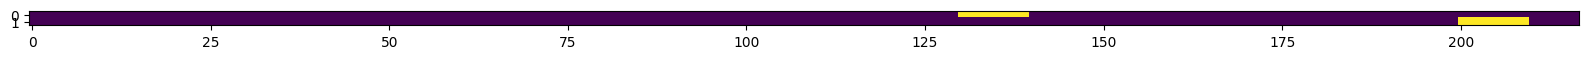

In [30]:
plt.figure(figsize=(20, 16))
plt.imshow(mask_time_indices.int().cpu())

In [31]:
print(f"Mask shape: {mask_time_indices.shape}")
print(f"Masked positions: {mask_time_indices.sum().item()}/{mask_time_indices.shape[-1]}")

Mask shape: torch.Size([2, 217])
Masked positions: 20/217


In [32]:
# Project features to encoder dimension (unmasked - for quantizer)
hidden_states = model.encoder.feature_projection(features)

# Apply masking: replace masked positions with learned mask embedding
# This is the KEY step - transformer sees MASKED features
hidden_states_masked = model._mask_hidden_states(hidden_states, mask_time_indices)

# Transformer processes masked hidden states
encoder_out = model.encoder.transformer(hidden_states_masked)

# project all transformed features (including masked) to final vq dim
transformer_features = model.project_hid(encoder_out)

# quantize all (UNMASKED) extracted features and project to final vq dim
# IMPORTANT: quantizer receives the ORIGINAL unmasked features, not the masked ones!
quantized_input = model.dropout_features(features)
quantized_features, codevector_perplexity = model.quantizer(quantized_input, mask_time_indices)
quantized_features = model.project_q(quantized_features)

In [33]:
print(f"Codevector perplexity: {codevector_perplexity.item():.2f}")

Codevector perplexity: 370.24


## Sample negatives

For training, we sample negatives sample K negatives (distractors) quantized states for contrastive loss. 
If attention_mask is passed, make sure that padded feature vectors cannot be sampled. Sample negative quantized vectors BTC => (BxT)C.

In [34]:
quantized_features.shape

torch.Size([2, 217, 256])

In [35]:
# Demonstrates negative sampling for contrastive loss
"""Sample negative examples for contrastive loss.

Args:
    features (Tensor): Features to sample from. Shape: (batch, seq_len, hidden_dim).
    num_negatives (int): Number of negatives per position.
    attention_mask (Tensor or None): Valid position mask. Shape: (batch, seq_len).
"""

batch_size, sequence_length, hidden_size = quantized_features.shape
# 1. Flatten features for indexing

# 2. Sample negative indices (per batch)
with torch.no_grad():
    sampled_negative_indices = []
    for batch_idx in range(batch_size):
        high = feature_mask[batch_idx].sum() - 1 if feature_mask is not None else sequence_length - 1
        sampled_indices_slice = torch.randint(
            0, high, size=(model.num_negatives * sequence_length,), device=quantized_features.device
        )
        sampled_negative_indices.append(sampled_indices_slice)

    sampled_negative_indices = torch.stack(sampled_negative_indices)

In [54]:
feat_lengths

tensor([197, 217])

In [53]:
high

tensor(216)

In [52]:
sampled_negative_indices

tensor([[ 83, 174,  94,  ...,  49,  29,  27],
        [232, 225, 315,  ..., 299, 272, 247]])

In [59]:
feature_indices.cpu().numpy()[:1000]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3,

In [62]:
sampled_negative_indices.shape

torch.Size([2, 21700])

Creates indices `[0,0,0,...,0, 1,1,1,...,1, ..., seq_len-1]` representing the positive position for each negative sample.

In [36]:
with torch.no_grad():
    # 3. Generate positive indices
    feature_indices = (
        torch.arange(sequence_length, device=quantized_features.device)[:, None]
        .expand(sequence_length, model.num_negatives)
        .flatten()
    )

    # 4. Avoid sampling the same positive vector
    sampled_negative_indices[sampled_negative_indices >= feature_indices] += 1

    # 5. Correct for batch size
    for batch_idx in range(1, batch_size):
        sampled_negative_indices[batch_idx] += batch_idx * sequence_length

    # 6. Gather negative vectors
    negative_quantized_features = quantized_features.view(-1, hidden_size)[sampled_negative_indices.view(-1)]
    negative_quantized_features = negative_quantized_features.view(
        batch_size, sequence_length, model.num_negatives, hidden_size
    ).permute(2, 0, 1, 3)

Features: `[batch=0: pos0, pos1, pos2, ... | batch=1: pos0, pos1, pos2, ...]`

For position 5 in batch 0:
  - Positive: `features[0, 5] = features[5]` (flattened)
  - Negatives: randomly sampled from `[0, 1, 2, ..., 4, 6, 7, ...]` (excluding 5)

The Shift Affects ALL Indices ≥ Positive

When positive is at index 5, the condition sampled_negative_indices >= feature_indices shifts all indices are 5 or greater by 1, not
just the exact match.

Example: Sampled `[3, 5, 6, 8]` with positive at `5`

sampled_negative_indices `= [3, 5, 6, 8]`
feature_indices           `= [5, 5, 5, 5]` same position for all negatives

  Condition: 
  ```
[3>=5,  5>=5, 6>=5, 8>=5]
[False, True, True, True]
  ```

```
After shift: [3, 6, 7, 9]
                 ↑  ↑  ↑
                 |  |  └── 8 → 9
                 |  └────── 6 → 7
                 └────────── 5 → 6
```
All indices shift together, so no collisions! The relative distances are preserved.

__Why this actually works?__

This technique effectively samples from the set `[0, 1, ..., i-1, i+1, ..., high+1]` — i.e., "all positions except i".

It's like saying: "If you picked an index at or above the positive position, use the next one instead" — which naturally excludes the positive while keeping all other positions distinct.

In [37]:
quantized_features.shape, negative_quantized_features.shape

(torch.Size([2, 217, 256]), torch.Size([100, 2, 217, 256]))

## Compute contrastive logits using cosine similarity

$$
\mathcal{L}_m = -\log \frac{\exp\!\left(\mathrm{sim}(c_t, q_t)/\kappa\right)}
{\sum_{\tilde{q}\sim Q_t} \exp\!\left(\mathrm{sim}(c_t, \tilde{q})/\kappa\right)}
$$

where we compute the cosine similarity
$$
\mathrm{sim}(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a}^\top \mathbf{b}}{\|\mathbf{a}\|\,\|\mathbf{b}\|},
$$
between context representations and quantized latent speech representations

In [38]:
target_features = torch.cat([quantized_features[None, :], negative_quantized_features], dim=0)

logits = torch.cosine_similarity(
    transformer_features.float(), target_features.float(), dim=-1
).type_as(target_features)

logits = logits / model.contrastive_logits_temperature

In [ ]:
# f = torch.cosine_similarity(
#     transformer_features.float(), target_features.float(), dim=-1
# ).type_as(target_features)
# f.transpose(0, 1).transpose(1, 2)[mask_time_indices.to(torch.bool)].mean() > 0.5

In [65]:
# Handle case where negative accidentally equals positive
# if a negative vector is identical to the positive (i.e. when codebook utilization is low),
# its cosine similarity will be masked
neg_is_pos = (quantized_features == negative_quantized_features).all(-1)
if neg_is_pos.any():
    logits[1:][neg_is_pos] = float("-inf")

# Prepare targets: masked positions should be predicted
preds = logits.transpose(0, 2).reshape(-1, logits.size(0))
target = ((1 - mask_time_indices.long()) * -100).transpose(0, 1).flatten()
contrastive_loss = F.cross_entropy(preds.float(), target, reduction="mean")

num_losses = mask_time_indices.sum()
contrastive_loss = contrastive_loss / num_losses

# Diversity loss encourages uniform codebook usage
num_codevectors = model.quantizer.num_groups * model.quantizer.num_vars

In [64]:
target.shape, preds.shape

(torch.Size([434]), torch.Size([434, 101]))

Compute diversity loss: $\mathbf{L}_d$

In [66]:
diversity_loss = (num_codevectors - codevector_perplexity) / num_codevectors

Total loss: $$\mathbf{L} = \mathbf{L}_m + \alpha * \mathbf{L}_d$$

In [67]:
total_loss = contrastive_loss + model.diversity_loss_weight * diversity_loss

In [68]:
print(f"Contrastive loss: {contrastive_loss.item():.4f}")
print(f"Diversity loss: {diversity_loss.item():.4f}")
print(f"Loss: {total_loss.item():.4f}")

Contrastive loss: 0.2479
Diversity loss: 0.4215
Loss: 0.2900


## Diversity loss

During pre-training, another loss is added to the contrastive loss to encourage the model to use all codewords equally often. This works by maximizing the entropy of the Gumbel-Softmax distribution, preventing the model to always choose from a small sub-group of all available codebook entries. You can find more details in the original paper.

# ASR Finetune Loss

In the original paper, the authors directly fine-tuned the model for speech recognition with a CTC loss, adding a linear projection on top of the context network to predict a word token at each timestep.